# Streaming and real time

Every notebook so far worked on a recording: something with a first sample and
a last one, that you can cut into chunks in whatever order suits you. A live
acquisition has neither end. The interrogator writes the next file whether or
not you are ready, and the only question you get to answer is what to do with
it before the one after arrives.

Almost nothing changes. The pipeline is the one from the previous notebook,
and so is `process`. What changes is the two ends — where the chunks come from
and where the results go — plus one thing an archive never asked of you:
deciding when to stop.

In [1]:
import shutil
import threading
import time
from pathlib import Path

import numpy as np

import xdas as xd

## A recording to play back

There is no interrogator behind this notebook, so we build one. Cut the event
into 4-second packets, and write each of them to `outputs/replay/` — this is
the *tape*, not the stream. Everything below plays it back.

In [2]:
da = xd.open("outputs/event.nc").load()
packets = xd.split(da, 16)
packets[0]

<xdas.DataArray (time: 250, distance: 10000)>
[[ 10121  10100    -42 ...  -1304   1441  -2011]
 [-16538 -16551    -35 ...  -1147  -4321   1827]
 [ 20025  20039     22 ...   1903  -1450  -2908]
 ...
 [-11057 -11142    -65 ...    761   4018   1492]
 [ 15091  15061    -52 ...   -145   1965   2862]
 [-11356 -11336     -1 ...     57  -1184  -4165]]
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:26:43.992
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

In [3]:
replay = Path("outputs/replay")
shutil.rmtree(replay, ignore_errors=True)
replay.mkdir(parents=True)

for index, packet in enumerate(packets):
    packet.to_netcdf(replay / f"{index:03d}.nc")

tape = sorted(replay.glob("*.nc"))
len(tape)

16

The instrument is a thread that drops one of those files into a directory
every so often, and then stops — a real one never would, which is the whole
point of the sections below.

In [4]:
def acquire(into, delay=0.25, skip=()):
    """Drop the tape into `into`, one file at a time, as an instrument would."""

    def run():
        for index, path in enumerate(tape):
            if index in skip:
                continue
            time.sleep(delay)
            shutil.copyfile(path, into / path.name)

    thread = threading.Thread(target=run)
    thread.start()
    return thread

## Watching a directory

The commonest way to get live data is also the dullest: the interrogator
writes files into a directory, and you take them as they land.
`xd.watch(path)` is that, as a source — every file closed under `path` is
opened and handed over as a chunk.

It is an *unbounded* source: it never runs out, it blocks. `process` notices,
and behaves accordingly — no total on the progress bar, since nobody knows
how much is coming, and `Ctrl-C` stops the loop cleanly rather than raising,
flushing the pipeline and returning what the sink has.

A notebook cannot press `Ctrl-C`, so we use the other way out: `until` names
a coordinate value to stop at, and the chunk containing it is truncated. It is
the clean way to bound anything unbounded — a fixed-length window of a live
feed, a test, or a cell that has to finish.

In [5]:
pipeline = (
    xd.resample(..., interval=250, snap=True, dim="distance")
    >> xd.filter(..., (1.0, None), ftype="iir", order=4, dim="time")
    >> np.abs
)
pipeline

Sequential:
  0: Resample(interval=250, snap=True, dim='distance')
  1: Filter(freq=(1.0, None))
  2: absolute(...)

In [6]:
incoming = Path("outputs/incoming")
shutil.rmtree(incoming, ignore_errors=True)
incoming.mkdir(parents=True)

source = xd.watch(incoming)      # start watching *before* anything arrives
instrument = acquire(incoming)   # ... then let the files start landing

live = pipeline.process(source, until=da["time"].values[-1])
instrument.join()
live

76.3MB [00:04, 19.3MB/s, read=73.2%, proc=26.8%, write=0.0%]


<xdas.DataArray (time: 4000, distance: 625)>
[[1088.575273   24.054773   11.868901 ...  972.135786  601.368745
    36.221027]
 [2103.140201  123.718653   39.457832 ...   76.833913  401.824247
    44.919561]
 [2432.215477  118.19305    66.782645 ...  516.341048  126.928268
   247.977904]
 ...
 [1143.766793   27.402197   11.012397 ...  162.529147  394.37716
   387.786622]
 [1301.565643   50.657764   21.160681 ...   81.554012   82.263968
   135.791466]
 [1360.213959   73.090843   13.31417  ...  309.942321  193.690964
   130.474723]]
Coordinates:
  * distance (distance): 0.000 to 152949.917
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:43.992

That ran in about as long as the acquisition took, because that is all it
could do: the pipeline spent most of its time waiting for the next file. The
progress bar's `read` percentage is the honest measure of how much headroom
you have — if `proc` ever approaches 100%, the processing is slower than the
instrument and the queue behind `watch` will grow without bound.

And the answer is the one the whole design promises. The stateful highpass
carried its state across every packet boundary, exactly as it did across the
chunk boundaries of the previous notebook:

In [7]:
offline = pipeline(da)
assert np.array_equal(live.values, offline.values, equal_nan=True)

```{warning}
`watch` reacts to a file being **closed**, which is narrower than it sounds.
The two other ways a file can turn up in a directory both fail, and quietly:

- a file *moved* in was never opened there, so it raises no event and is
  simply never seen;
- a file written in place in more than one pass — which is what `to_netcdf`
  does, metadata first and data second — is opened after the first pass,
  when it is not yet a data array. The read raises, inside the watching
  thread, which ends it; `process` then waits for a queue nothing will ever
  fill again.

That is why the instrument above *copies*: a copy is one open, one write, one
close. Point `watch` at a directory an acquisition system fills, not at one
you are writing into yourself.
```

## When the stream skips

An archive lets you find its gaps before you process it: the coordinate says
where the acquisition stopped, and `process` announces the seams up front. A
live source cannot be read ahead of itself, so a gap is only knowable when the
chunk after it arrives.

Let the instrument lose one packet:

In [8]:
lossy = Path("outputs/incoming_lossy")
shutil.rmtree(lossy, ignore_errors=True)
lossy.mkdir(parents=True)

source = xd.watch(lossy)
instrument = acquire(lossy, skip=(8,))

patchy = pipeline.process(source, until=da["time"].values[-1])
instrument.join()

38.1MB [00:02, 19.6MB/s, read=72.9%, proc=27.1%, write=0.0%]/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/xdas/processing/core.py:309: UserWarning: realtime source has a discontinuity along 'time' at 2023-11-03T12:27:16.008000000; state is flushed and reset
  previous = _announce_realtime_seam(previous, chunk, chunk_dim)
71.5MB [00:03, 19.2MB/s, read=73.4%, proc=26.6%, write=0.0%]


The warning is the point. The packet after the gap does not continue the one
before it, so the atoms holding state are flushed and restarted rather than
asked to filter across four seconds that never happened — which is the same
thing they do at an archive's seams, decided one chunk later.

What comes back is shorter than the continuous run by exactly the packet that
never arrived, and it is *not* what you get by filtering the whole event and
cutting the gap out afterwards: the filter has no history to carry across a
discontinuity, so it restarts there.

In [9]:
print(f"{live.sizes['time']} samples continuous, {patchy.sizes['time']} with the gap")

4000 samples continuous, 3750 with the gap


## Over the network

Files are one transport. The other is a socket: xdas publishes and subscribes
to `DataArray` chunks over ZeroMQ, so the acquisition, the processing and
whatever looks at the result can be three programs on three machines.

Both ends are ordinary `process` arguments — a `"tcp://..."` address as
`source` subscribes, the same as `out` publishes — and this is the one place
where real time asks something of you. A ZeroMQ publisher drops whatever it
sends before a subscriber's subscription has reached it. Which of the two
waits depends on which one cannot afford to lose anything:

- a **recording** being replayed has a head that exists only once, so the
  *publisher* waits, with `wait_for_subscribers()`;
- a **live instrument** waits for nobody — it streams what it measures — so
  the *subscriber* is the one that waits, with `wait_until_subscribed()`,
  and picks the stream up wherever it lands.

Below, three nodes: an interrogator replaying the tape, a processing node
running the same pipeline, and a display collecting what comes out.

In [10]:
from xdas.io import get_free_port
from xdas.processing import ZMQPublisher, ZMQSubscriber

raw = f"tcp://localhost:{get_free_port()}"
processed = f"tcp://localhost:{get_free_port()}"

In [11]:
def interrogator():
    with ZMQPublisher(raw) as publisher:
        publisher.wait_for_subscribers()  # a tape cannot afford to lose its head
        for packet in packets:
            publisher.submit(packet)


seen = []


def display():
    with ZMQSubscriber(processed, timeout=60.0) as subscriber:
        for chunk in subscriber:
            seen.append(chunk)
            if len(seen) == len(packets):
                break

The middle node publishes too, and its own subscriber must not miss the start
either. `out="tcp://..."` would have `process` build the publisher itself,
which leaves nothing to wait on; passing a ready `ZMQPublisher` instead — the
way any sink needing configuration is passed — puts that wait back in reach.

In [12]:
nodes = [threading.Thread(target=interrogator), threading.Thread(target=display)]
for node in nodes:
    node.start()

with ZMQPublisher(processed) as publisher:
    publisher.wait_for_subscribers()  # the display is listening
    result = pipeline.process(raw, out=publisher, until=da["time"].values[-1])

for node in nodes:
    node.join()

print(f"{len(seen)} chunks arrived at the display, and process returned {result}")

76.3MB [00:03, 24.2MB/s, read=46.8%, proc=33.6%, write=19.6%]


16 chunks arrived at the display, and process returned None


`process` returns `None` because a publisher has nothing to aggregate: the
result left over the wire, chunk by chunk, as it was produced. It is the
display that has the answer — and it is the same answer again, over three
sockets this time:

In [13]:
assert np.array_equal(xd.concat(seen).values, offline.values, equal_nan=True)

```{note}
Real instruments speak their own protocol rather than this one.
`xdas.io.asn.ZMQSubscriber` subscribes to an ASN OptoDAS interrogator
directly, decoding its headers and packets, and exposes the same iterator of
`DataArray` chunks — so it drops into `process` in place of the address
above, and nothing downstream changes.
```

## A detector on the live stream

Nothing so far was specific to filtering, so put the phase picker of notebook
03 on the stream instead, and write what it finds to a CSV as it finds it.
The picker needs a minute of context that a four-second packet does not have;
it buffers across the packets and emits when it can, which is why the sink is
a table that grows rather than an array.

In [14]:
from seisbench.models import PhaseNet

model = PhaseNet.from_pretrained("diting")

detector = xd.resample(..., interval=500, snap=True, dim="distance") >> xd.pick(
    ..., model, thresh={"P": 0.3, "S": 0.3}, device="cpu", dim="time"
)

In [15]:
%rm -f outputs/live_picks.csv

In [16]:
instrument = threading.Thread(target=interrogator)
instrument.start()

picks = detector.process(raw, out="outputs/live_picks.csv", until=da["time"].values[-1])
instrument.join()

len(picks)

76.3MB [00:04, 16.1MB/s, read=25.7%, proc=74.3%, write=0.0%]


362

The same picks the detector gives on the whole array at once, and by now the
reason is unsurprising: a picker that carries its buffer across a packet
boundary cannot tell one apart from a chunk boundary, and neither can tell
either apart from no boundary at all.

In [17]:
whole = detector(da)
assert len(picks) == len(whole)

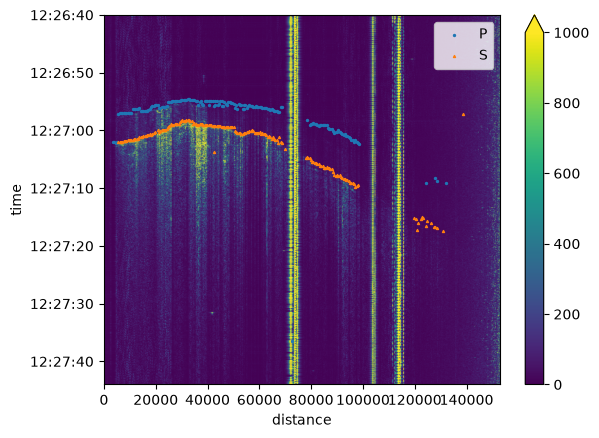

In [18]:
import matplotlib.pyplot as plt

offline.plot(yincrease=False, vmin=0, vmax=1e3, interpolation="antialiased")

for phase, marker in [("P", "o"), ("S", "^")]:
    sub = picks[picks["phase"] == phase]
    plt.scatter(sub["distance"], sub["time"], s=2, marker=marker, label=phase)

plt.legend()
plt.show()

## What a real deployment changes

Not much, and that is the summary:

- **the source** — `xd.watch(dir)` for an acquisition system writing files, a
  `"tcp://..."` address for a socket, `xdas.io.asn.ZMQSubscriber` for an ASN
  interrogator. Anything iterating `DataArray` chunks will do, including one
  you write yourself.
- **the sink** — a directory for a netcdf archive, a `.csv` for a table of
  detections, an address to hand the processed stream to the next node. A
  result in memory is the one option a stream that never ends cannot have.
- **the stop** — `until` for a bounded window, `Ctrl-C` for a service you
  interrupt, and neither for one that is meant to run until the machine is
  turned off.

The pipeline in the middle is the one you tested on a file, unchanged, and it
gives the answer it gave there.